# Bounding Box Regression with Pretrained ResNet

## Overview
Finetuning a pretrained ResNet model on Oxford-IIIT Pets face bounding box regression.

## Model Architecture
- Pretrained ResNet-18 backbone (ImageNet weights)
- Simple bounding box regression head
- Task: Given a pet image, predict the face bounding box coordinates

## Cell 1: Setup & Imports

In [1]:
import math
import random
import os
import tarfile
import urllib.request
from datetime import datetime
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm

import wandb

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

# Set seeds for reproducibility
seed = 3407
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

print(f"Seeds set to {seed}")

Device: cuda
Seeds set to 3407


## Cell 2: Dataset Download and Loading

In [2]:
# Dataset location
DATA_DIR = "/lus/lfs1aip2/home/s5e/jrosser.s5e/oxford_pets"

def download_oxford_pets(data_dir):
    """Download Oxford-IIIT Pets dataset if not present."""
    os.makedirs(data_dir, exist_ok=True)
    
    images_dir = os.path.join(data_dir, "images")
    annotations_dir = os.path.join(data_dir, "annotations")
    
    # Check if already downloaded
    if os.path.exists(images_dir) and os.path.exists(annotations_dir):
        print(f"Dataset already exists at {data_dir}")
        return
    
    print("Downloading Oxford-IIIT Pets dataset...")
    
    # Download images
    images_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz"
    images_tar = os.path.join(data_dir, "images.tar.gz")
    if not os.path.exists(images_tar):
        print(f"Downloading images from {images_url}...")
        urllib.request.urlretrieve(images_url, images_tar)
    
    print("Extracting images...")
    with tarfile.open(images_tar, "r:gz") as tar:
        tar.extractall(data_dir)
    
    # Download annotations
    annotations_url = "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz"
    annotations_tar = os.path.join(data_dir, "annotations.tar.gz")
    if not os.path.exists(annotations_tar):
        print(f"Downloading annotations from {annotations_url}...")
        urllib.request.urlretrieve(annotations_url, annotations_tar)
    
    print("Extracting annotations...")
    with tarfile.open(annotations_tar, "r:gz") as tar:
        tar.extractall(data_dir)
    
    print("Download complete!")

# Download if needed
download_oxford_pets(DATA_DIR)

Dataset already exists at /lus/lfs1aip2/home/s5e/jrosser.s5e/oxford_pets


In [ ]:
def parse_bbox_from_xml(xml_path):
    """Parse bounding box from Oxford Pets XML annotation file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Get image size
    size = root.find('size')
    width = int(size.find('width').text)
    height = int(size.find('height').text)
    
    # Get bounding box (head bbox)
    obj = root.find('object')
    if obj is None:
        return None, None, None
    
    bndbox = obj.find('bndbox')
    xmin = int(bndbox.find('xmin').text)
    ymin = int(bndbox.find('ymin').text)
    xmax = int(bndbox.find('xmax').text)
    ymax = int(bndbox.find('ymax').text)
    
    return (xmin, ymin, xmax, ymax), width, height


class OxfordPetsDataset(Dataset):
    """Oxford-IIIT Pets dataset for bounding box regression."""
    
    def __init__(self, data_dir, split='trainval', image_size=224):
        """
        Args:
            data_dir: Path to dataset root
            split: 'trainval' or 'test'
            image_size: Target image size
        """
        self.data_dir = data_dir
        self.image_size = image_size
        
        # Paths
        self.images_dir = os.path.join(data_dir, "images")
        self.annotations_dir = os.path.join(data_dir, "annotations", "xmls")
        
        # Load split file
        split_file = os.path.join(data_dir, "annotations", f"{split}.txt")
        
        # Parse samples
        self.samples = []
        with open(split_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 1:
                    image_name = parts[0]
                    image_path = os.path.join(self.images_dir, f"{image_name}.jpg")
                    xml_path = os.path.join(self.annotations_dir, f"{image_name}.xml")
                    
                    # Only include if both image and annotation exist
                    if os.path.exists(image_path) and os.path.exists(xml_path):
                        bbox, w, h = parse_bbox_from_xml(xml_path)
                        if bbox is not None:
                            self.samples.append({
                                'image_path': image_path,
                                'bbox': bbox,
                                'orig_width': w,
                                'orig_height': h,
                            })
        
        print(f"Loaded {len(self.samples)} samples for {split} split")
        
        # ImageNet normalization (required for pretrained models)
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # Load image
        image = Image.open(sample['image_path']).convert('RGB')
        orig_w, orig_h = image.size
        
        # Get bbox and normalize to [0, 1]
        xmin, ymin, xmax, ymax = sample['bbox']
        bbox = torch.tensor([
            xmin / orig_w,
            ymin / orig_h,
            xmax / orig_w,
            ymax / orig_h,
        ], dtype=torch.float32)
        
        # Resize image
        image = image.resize((self.image_size, self.image_size), Image.BILINEAR)
        
        # Convert to tensor
        image = transforms.ToTensor()(image)
        
        # Normalize with ImageNet stats
        image = self.normalize(image)
        
        return image, bbox


# Test loading
print("\nTesting dataset loading...")
test_dataset = OxfordPetsDataset(DATA_DIR, split='trainval', image_size=224)
print(f"Dataset size: {len(test_dataset)}")

# Show sample with red bounding box
import matplotlib.pyplot as plt
import numpy as np

# Get sample (normalized tensors)
img, bbox = test_dataset[0]
print(f"Image shape: {img.shape}")
print(f"BBox (normalized): {bbox}")

# Convert image tensor to numpy for plotting
unnormalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
img_disp = unnormalize(img).clamp(0, 1).permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1)
ax.imshow(img_disp)

# bbox is normalized [xmin, ymin, xmax, ymax]
h, w = img_disp.shape[:2]
xmin = bbox[0].item() * w
ymin = bbox[1].item() * h
xmax = bbox[2].item() * w
ymax = bbox[3].item() * h

rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                     linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
ax.set_title("Sample Image with Red Bounding Box")
plt.axis('off')
plt.show()

## Cell 3: Model Architecture - Pretrained ResNet with BBox Head

In [4]:
class ResNetBBoxRegressor(nn.Module):
    """Pretrained ResNet with bounding box regression head."""
    
    def __init__(self, backbone='resnet18', pretrained=True, num_outputs=4):
        super().__init__()
        
        # Load pretrained backbone
        if backbone == 'resnet18':
            self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
            feature_dim = 512
        elif backbone == 'resnet34':
            self.backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
            feature_dim = 512
        elif backbone == 'resnet50':
            self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
            feature_dim = 2048
        else:
            raise ValueError(f"Unknown backbone: {backbone}")
        
        # Remove the final classification layer
        self.backbone.fc = nn.Identity()
        
        # Bounding box regression head
        self.bbox_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_outputs),
        )
    
    def forward(self, x):
        # Extract features
        features = self.backbone(x)  # [B, feature_dim]
        
        # Predict bbox
        bbox = self.bbox_head(features)  # [B, 4]
        
        # Sigmoid to constrain to [0, 1]
        bbox = torch.sigmoid(bbox)
        
        return bbox


# Count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Test model
print("Testing model...")
test_model = ResNetBBoxRegressor(backbone='resnet18', pretrained=True)
n_params = count_parameters(test_model)
print(f"Model parameters: {n_params:,}")

# Test forward pass
test_input = torch.randn(2, 3, 224, 224)
test_output = test_model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]")

Testing model...
Model parameters: 11,308,868
Input shape: torch.Size([2, 3, 224, 224])
Output shape: torch.Size([2, 4])
Output range: [0.459, 0.576]


## Cell 4: Training Configuration

In [ ]:
# Configuration
config = {
    # Model
    "backbone": "resnet18",
    "pretrained": True,
    "image_size": 224,
    "freeze_backbone": True,  # Only train the head
    
    # Training
    "batch_size": 32,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "max_epochs": 20,
    "grad_clip": 1.0,
    
    # Logging
    "log_interval": 50,
    "eval_interval": 100,
    
    # Paths
    "data_dir": DATA_DIR,
    "output_dir": "./bounding_box_finetune_checkpoints",
    "wandb_project": "bounding-box-finetune",
    "wandb_run_name": f"bbox_finetune_{datetime.now().strftime('%Y%m%d_%H%M%S')}",
}

# Create output directory
os.makedirs(config["output_dir"], exist_ok=True)

print("Configuration:")
for k, v in config.items():
    print(f"  {k}: {v}")

## Cell 5: Initialize Model, Datasets, and Wandb

In [ ]:
# Initialize wandb
wandb.init(
    project=config["wandb_project"],
    name=config["wandb_run_name"],
    config=config,
)

# Create full dataset from trainval (test split has no XML annotations)
full_dataset = OxfordPetsDataset(
    config["data_dir"],
    split='trainval',
    image_size=config["image_size"],
)

# Split into train (80%) and val (20%)
n_total = len(full_dataset)
n_val = int(0.2 * n_total)
n_train = n_total - n_val

# Use random_split with generator for reproducibility
generator = torch.Generator().manual_seed(seed)
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [n_train, n_val], generator=generator
)

print(f"Split trainval into: {n_train} train, {n_val} val")

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Train batches per epoch: {len(train_loader)}")

In [7]:
# Create model
model = ResNetBBoxRegressor(
    backbone=config["backbone"],
    pretrained=config["pretrained"],
).to(device)

# Freeze backbone if configured
if config.get("freeze_backbone", False):
    for param in model.backbone.parameters():
        param.requires_grad = False
    print("Backbone frozen - only training bbox_head")

n_params = count_parameters(model)
print(f"Trainable parameters: {n_params:,}")

# Log model architecture to wandb
wandb.watch(model, log="all", log_freq=100)

Backbone frozen - only training bbox_head
Trainable parameters: 132,356


## Cell 6: Metrics and Loss Functions

In [8]:
def compute_iou(pred_bbox, target_bbox):
    """Compute Intersection over Union for bounding boxes.
    
    Args:
        pred_bbox: [B, 4] predicted boxes (xmin, ymin, xmax, ymax)
        target_bbox: [B, 4] target boxes
    
    Returns:
        IoU scores [B]
    """
    pred_x1, pred_y1, pred_x2, pred_y2 = pred_bbox.unbind(dim=1)
    tgt_x1, tgt_y1, tgt_x2, tgt_y2 = target_bbox.unbind(dim=1)
    
    inter_x1 = torch.max(pred_x1, tgt_x1)
    inter_y1 = torch.max(pred_y1, tgt_y1)
    inter_x2 = torch.min(pred_x2, tgt_x2)
    inter_y2 = torch.min(pred_y2, tgt_y2)
    
    inter_width = (inter_x2 - inter_x1).clamp(min=0)
    inter_height = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_width * inter_height
    
    pred_area = (pred_x2 - pred_x1).clamp(min=0) * (pred_y2 - pred_y1).clamp(min=0)
    tgt_area = (tgt_x2 - tgt_x1) * (tgt_y2 - tgt_y1)
    union_area = pred_area + tgt_area - inter_area
    
    iou = inter_area / (union_area + 1e-8)
    return iou


def bbox_loss(pred, target):
    """SmoothL1 loss for bounding box regression."""
    loss = F.smooth_l1_loss(pred, target, reduction='mean')
    iou = compute_iou(pred, target).mean()
    return loss, iou


# Test loss function
test_pred = torch.tensor([[0.1, 0.1, 0.5, 0.5], [0.2, 0.2, 0.6, 0.6]])
test_target = torch.tensor([[0.1, 0.1, 0.5, 0.5], [0.3, 0.3, 0.7, 0.7]])
loss, iou = bbox_loss(test_pred, test_target)
print(f"Test loss: loss={loss:.4f}, mean_iou={iou:.4f}")

Test loss: loss=0.0025, mean_iou=0.6957


## Cell 7: Trainer Class

In [9]:
class BBoxTrainer:
    """Trainer for bounding box regression with pretrained ResNet."""
    
    def __init__(self, model, train_loader, val_loader, config, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.config = config
        self.device = device
        
        # Only optimize parameters that require gradients
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        
        self.optimizer = torch.optim.Adam(
            trainable_params,
            lr=config["learning_rate"],
            weight_decay=config.get("weight_decay", 0),
        )
        
        # Cosine annealing scheduler
        self.total_steps = len(train_loader) * config["max_epochs"]
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer,
            T_max=self.total_steps,
            eta_min=1e-6,
        )
        
        self.global_step = 0
        self.best_iou = 0.0
    
    @torch.no_grad()
    def evaluate(self):
        """Evaluate on validation set."""
        self.model.eval()
        total_loss = 0
        total_iou = 0
        n_batches = 0
        
        for images, bboxes in self.val_loader:
            images = images.to(self.device)
            bboxes = bboxes.to(self.device)
            
            pred = self.model(images)
            loss, iou = bbox_loss(pred, bboxes)
            
            total_loss += loss.item()
            total_iou += iou.item()
            n_batches += 1
        
        self.model.train()
        
        if n_batches == 0:
            return {'loss': 0.0, 'iou': 0.0}
        
        return {
            'loss': total_loss / n_batches,
            'iou': total_iou / n_batches,
        }
    
    def save_checkpoint(self, epoch, is_best=False):
        """Save model checkpoint."""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'global_step': self.global_step,
            'best_iou': self.best_iou,
            'config': self.config,
        }
        
        path = os.path.join(self.config["output_dir"], f"checkpoint_epoch_{epoch}.pt")
        torch.save(checkpoint, path)
        print(f"Saved checkpoint to {path}")
        
        if is_best:
            best_path = os.path.join(self.config["output_dir"], "best_model.pt")
            torch.save(checkpoint, best_path)
            print(f"Saved best model to {best_path}")
            wandb.save(best_path)
    
    def train_epoch(self, epoch):
        """Train for one epoch."""
        self.model.train()
        total_loss = 0
        total_iou = 0
        n_batches = 0
        
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}")
        for images, bboxes in pbar:
            images = images.to(self.device)
            bboxes = bboxes.to(self.device)
            
            # Forward pass
            pred = self.model(images)
            loss, iou = bbox_loss(pred, bboxes)
            
            # Backward pass
            self.optimizer.zero_grad()
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config["grad_clip"])
            
            self.optimizer.step()
            self.scheduler.step()
            
            total_loss += loss.item()
            total_iou += iou.item()
            n_batches += 1
            self.global_step += 1
            
            # Update progress bar
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "iou": f"{iou.item():.4f}"})
            
            # Log to wandb
            if self.global_step % self.config["log_interval"] == 0:
                wandb.log({
                    "train/loss": loss.item(),
                    "train/iou": iou.item(),
                    "train/lr": self.scheduler.get_last_lr()[0],
                    "train/epoch": epoch,
                    "train/global_step": self.global_step,
                })
            
            # Evaluate periodically
            if self.global_step % self.config["eval_interval"] == 0:
                metrics = self.evaluate()
                wandb.log({
                    "val/loss": metrics['loss'],
                    "val/iou": metrics['iou'],
                    "train/global_step": self.global_step,
                })
                print(f"\nStep {self.global_step}: val_loss={metrics['loss']:.4f}, val_iou={metrics['iou']:.4f}")
        
        return total_loss / n_batches, total_iou / n_batches
    
    def train(self):
        """Full training loop."""
        print(f"Starting training for {self.config['max_epochs']} epochs...")
        print(f"Total steps: {self.total_steps}")
        
        for epoch in range(1, self.config['max_epochs'] + 1):
            train_loss, train_iou = self.train_epoch(epoch)
            metrics = self.evaluate()
            
            print(f"\nEpoch {epoch}: train_loss={train_loss:.4f}, train_iou={train_iou:.4f}")
            print(f"          val_loss={metrics['loss']:.4f}, val_iou={metrics['iou']:.4f}")
            
            # Log epoch metrics
            wandb.log({
                "epoch/train_loss": train_loss,
                "epoch/train_iou": train_iou,
                "epoch/val_loss": metrics['loss'],
                "epoch/val_iou": metrics['iou'],
                "epoch/epoch": epoch,
            })
            
            # Save checkpoint every epoch
            is_best = metrics['iou'] > self.best_iou
            if is_best:
                self.best_iou = metrics['iou']
            self.save_checkpoint(epoch, is_best=is_best)
        
        print(f"\nTraining complete! Best IoU: {self.best_iou:.4f}")


print("Trainer class defined.")

Trainer class defined.


## Cell 8: Train the Model

In [10]:
# Create trainer
trainer = BBoxTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    device=device,
)

# Train
trainer.train()

Starting training for 20 epochs...
Total steps: 1840


Epoch 1: 100%|██████████| 92/92 [00:06<00:00, 13.70it/s, loss=0.0096, iou=0.3588]



Epoch 1: train_loss=0.0113, train_iou=0.3624
          val_loss=0.0086, val_iou=0.3749
Saved checkpoint to ./bounding_box_finetune_checkpoints/checkpoint_epoch_1.pt
Saved best model to ./bounding_box_finetune_checkpoints/best_model.pt


Epoch 2:   9%|▊         | 8/92 [00:01<00:13,  6.29it/s, loss=0.0089, iou=0.3918]


Step 100: val_loss=0.0082, val_iou=0.4148


...


Epoch 19: train_loss=0.0052, train_iou=0.4715
          val_loss=0.0065, val_iou=0.4487
Saved checkpoint to ./bounding_box_finetune_checkpoints/checkpoint_epoch_19.pt


Epoch 20:  57%|█████▋    | 52/92 [00:04<00:04,  9.40it/s, loss=0.0058, iou=0.5011]


Step 1800: val_loss=0.0065, val_iou=0.4501


Epoch 20: 100%|██████████| 92/92 [00:06<00:00, 13.71it/s, loss=0.0072, iou=0.3732]



Epoch 20: train_loss=0.0053, train_iou=0.4712
          val_loss=0.0065, val_iou=0.4504
Saved checkpoint to ./bounding_box_finetune_checkpoints/checkpoint_epoch_20.pt

Training complete! Best IoU: 0.4510


## Cell 9: Evaluation and Visualization

Loaded best model from epoch 12
Best IoU: 0.4510


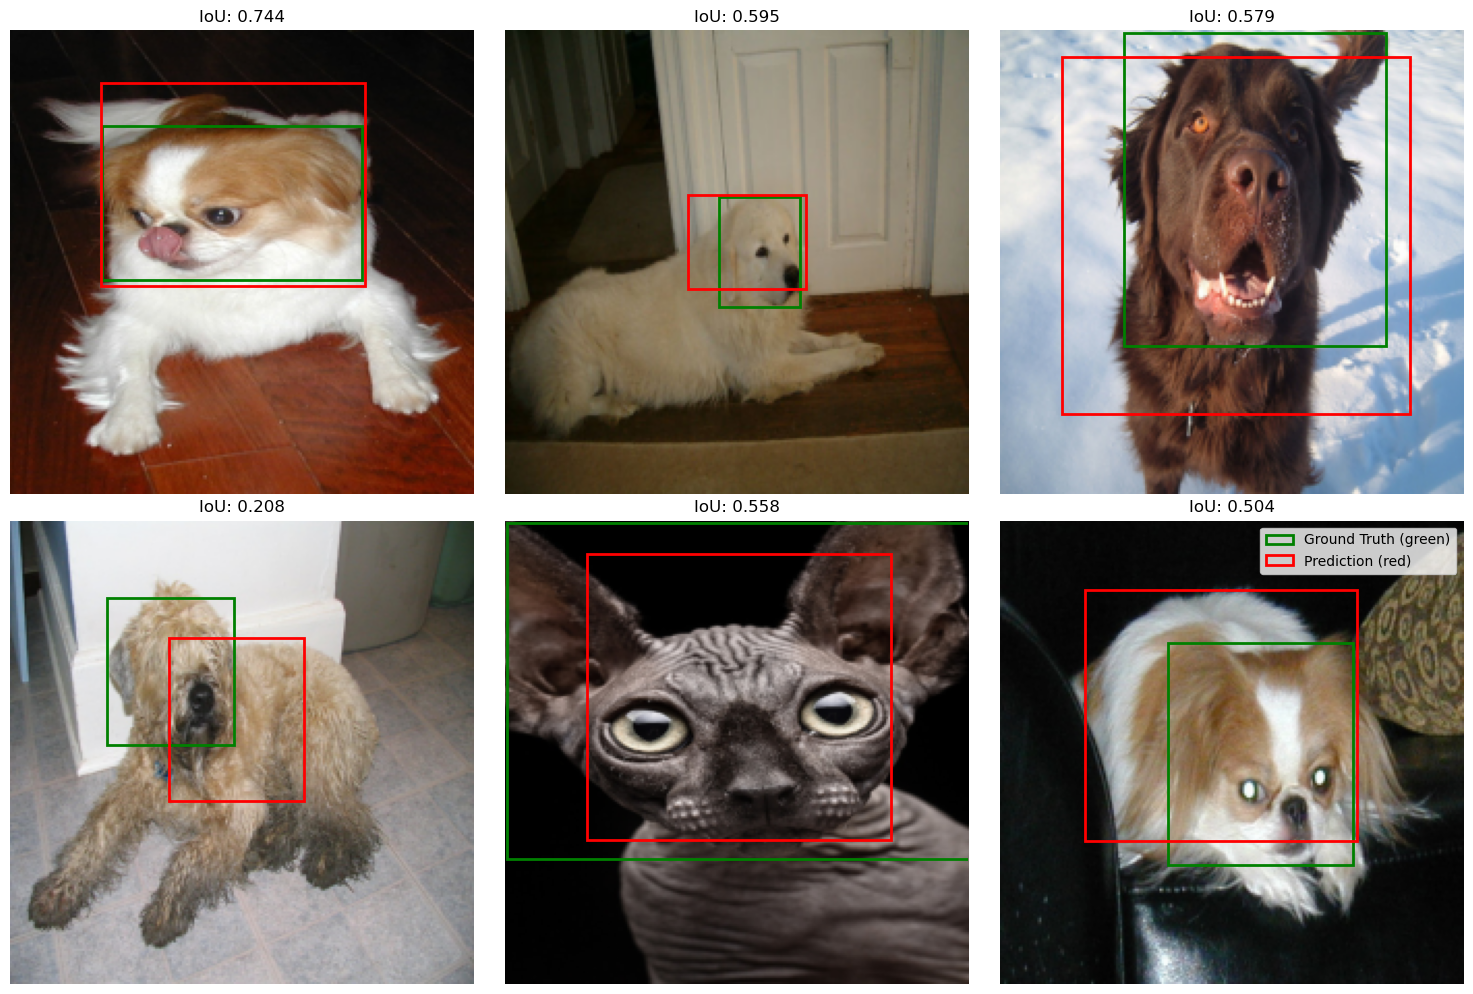

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load best model
best_checkpoint_path = os.path.join(config["output_dir"], "best_model.pt")
if os.path.exists(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best IoU: {checkpoint['best_iou']:.4f}")

model.eval()


def visualize_predictions(model, dataset, n_samples=6):
    """Visualize model predictions vs ground truth."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    # Get random samples
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    
    for ax, idx in zip(axes, indices):
        # Get sample
        image, target_bbox = dataset[idx]
        
        # Predict
        with torch.no_grad():
            pred_bbox = model(image.unsqueeze(0).to(device))[0].cpu()
        
        # Denormalize image for visualization
        img_vis = image.clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_vis = img_vis * std + mean
        img_vis = img_vis.permute(1, 2, 0).numpy()
        img_vis = np.clip(img_vis, 0, 1)
        
        # Show image
        ax.imshow(img_vis)
        
        # Draw ground truth bbox (green)
        h, w = config["image_size"], config["image_size"]
        gt_rect = patches.Rectangle(
            (target_bbox[0] * w, target_bbox[1] * h),
            (target_bbox[2] - target_bbox[0]) * w,
            (target_bbox[3] - target_bbox[1]) * h,
            linewidth=2, edgecolor='green', facecolor='none', label='GT'
        )
        ax.add_patch(gt_rect)
        
        # Draw predicted bbox (red)
        pred_rect = patches.Rectangle(
            (pred_bbox[0] * w, pred_bbox[1] * h),
            (pred_bbox[2] - pred_bbox[0]) * w,
            (pred_bbox[3] - pred_bbox[1]) * h,
            linewidth=2, edgecolor='red', facecolor='none', label='Pred'
        )
        ax.add_patch(pred_rect)
        
        # Compute IoU
        iou = compute_iou(pred_bbox.unsqueeze(0), target_bbox.unsqueeze(0)).item()
        ax.set_title(f"IoU: {iou:.3f}")
        ax.axis('off')
    
    plt.legend(['Ground Truth (green)', 'Prediction (red)'], loc='upper right')
    plt.tight_layout()
    plt.savefig(os.path.join(config["output_dir"], "predictions.png"), dpi=150)
    plt.show()
    
    # Log to wandb
    wandb.log({"predictions": wandb.Image(fig)})


# Visualize on validation set
visualize_predictions(model, val_dataset)


FINAL EVALUATION ON VALIDATION SET


Evaluating: 100%|██████████| 23/23 [00:00<00:00, 40.91it/s]



Results on 734 validation samples:
  Mean IoU: 0.4511
  Std IoU: 0.2280
  IoU@0.5: 47.68%
  IoU@0.75: 8.45%


KeyboardInterrupt: 

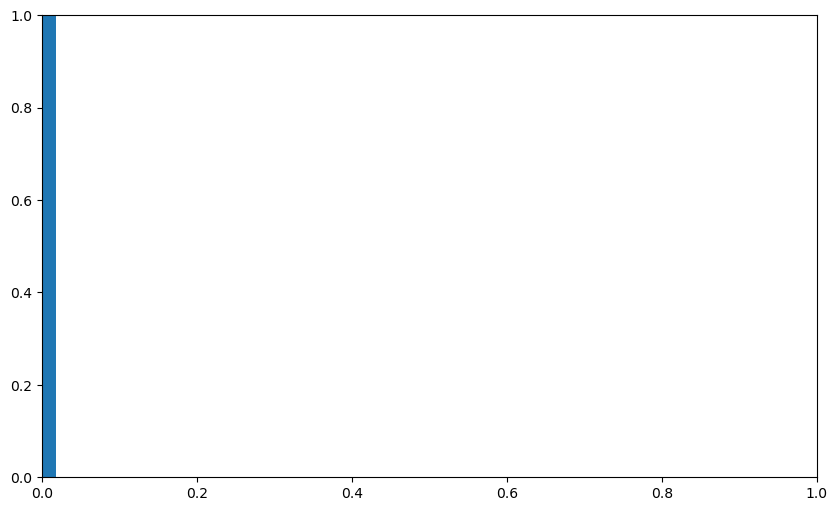

In [12]:
# Final evaluation with IoU distribution
print("\n" + "="*80)
print("FINAL EVALUATION ON VALIDATION SET")
print("="*80)

all_ious = []
model.eval()

with torch.no_grad():
    for images, bboxes in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        bboxes = bboxes.to(device)
        
        pred = model(images)
        ious = compute_iou(pred, bboxes)
        all_ious.extend(ious.cpu().tolist())

all_ious = np.array(all_ious)

print(f"\nResults on {len(all_ious)} validation samples:")
print(f"  Mean IoU: {all_ious.mean():.4f}")
print(f"  Std IoU: {all_ious.std():.4f}")
print(f"  IoU@0.5: {(all_ious >= 0.5).mean()*100:.2f}%")
print(f"  IoU@0.75: {(all_ious >= 0.75).mean()*100:.2f}%")

# Plot IoU distribution
plt.figure(figsize=(10, 6))
plt.hist(all_ious, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='red', linestyle='--', label='IoU=0.5')
plt.axvline(x=all_ious.mean(), color='green', linestyle='--', label=f'Mean={all_ious.mean():.3f}')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.title('IoU Distribution on Validation Set')
plt.legend()
plt.savefig(os.path.join(config["output_dir"], "iou_distribution.png"), dpi=150)
plt.show()

# Log final metrics
wandb.log({
    "final/mean_iou": all_ious.mean(),
    "final/std_iou": all_ious.std(),
    "final/iou_at_0.5": (all_ious >= 0.5).mean(),
    "final/iou_at_0.75": (all_ious >= 0.75).mean(),
})

## Cell 10: Finish and Cleanup

In [ ]:
# Log final summary
wandb.summary["final_mean_iou"] = all_ious.mean()
wandb.summary["final_iou_at_0.5"] = (all_ious >= 0.5).mean()
wandb.summary["total_steps"] = trainer.global_step

# Finish wandb run
wandb.finish()

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80)
print(f"Best IoU: {trainer.best_iou:.4f}")
print(f"Final Mean IoU: {all_ious.mean():.4f}")
print(f"IoU@0.5 Accuracy: {(all_ious >= 0.5).mean()*100:.2f}%")
print(f"Checkpoints saved to: {config['output_dir']}")
print(f"Wandb run: {config['wandb_run_name']}")

epoch/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch/train_iou,▃▂▃▁▄▇▇▇▇▇▇█████████
epoch/train_loss,▇▇▇█▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_iou,▄▄▄▁▇█████▇█████████
epoch/val_loss,▆▆▆█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
final/iou_at_0.5,▁
final/iou_at_0.75,▁
final/mean_iou,▁
final/std_iou,▁
train/epoch,▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
+6,...



TRAINING COMPLETE
Best IoU: 0.4374
Final Mean IoU: 0.4376
IoU@0.5 Accuracy: 45.37%
Checkpoints saved to: ./bounding_box_finetune_checkpoints
Wandb run: bbox_finetune_20260106_150911
